In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r'C:\Users\kashi\OneDrive\图片\Desktop\techcadd\chocolate_sales_2025_dataset.csv')
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [5]:
df['Brand'] = le.fit_transform(df['Brand'])
df['Country'] = le.fit_transform(df['Country'])
df['Sales_Channel'] = le.fit_transform(df['Sales_Channel'])
df['Payment_Method'] = le.fit_transform(df['Payment_Method'])
df['Product_Type']=le.fit_transform(df['Product_Type'])
#pd.get_dummies(df,columns=['Product_Type','Country','Sales_Channel','Payment_Method'])
df['Payment_Method']

0      2
1      1
2      2
3      1
4      1
      ..
495    2
496    1
497    0
498    1
499    1
Name: Payment_Method, Length: 500, dtype: int64

In [6]:
df.drop(columns='Date',inplace=True)

In [7]:
x = df.drop(columns='Revenue_USD')
x

,Sale_ID,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold
0,1,0,3,2,3,2,5.00,194
1,2,3,0,4,1,1,17.73,144
2,3,6,2,0,3,2,7.42,134
3,4,1,4,5,0,1,18.28,112
4,5,0,3,2,0,1,18.21,92
...,...,...,...,...,...,...,...,...
495,496,0,3,2,2,2,6.03,30
496,497,6,5,7,0,1,18.75,191
497,498,6,4,3,1,0,3.62,151
498,499,5,1,5,2,1,12.12,80


In [8]:
y = df[['Revenue_USD']]

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [10]:
df

,Sale_ID,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,0,3,2,3,2,5.00,194,970.00
1,2,3,0,4,1,1,17.73,144,2553.12
2,3,6,2,0,3,2,7.42,134,994.28
3,4,1,4,5,0,1,18.28,112,2047.36
4,5,0,3,2,0,1,18.21,92,1675.32
...,...,...,...,...,...,...,...,...,...
495,496,0,3,2,2,2,6.03,30,180.90
496,497,6,5,7,0,1,18.75,191,3581.25
497,498,6,4,3,1,0,3.62,151,546.62
498,499,5,1,5,2,1,12.12,80,969.60


In [11]:
#df[df['Date']=='2025-11-24'].value_counts()


In [12]:
#df.drop([1,198,394],inplace=True)

In [13]:
#df.reset_index(drop=True,inplace=True)

In [14]:
df.columns

Index(['Sale_ID', 'Brand', 'Product_Type', 'Country', 'Sales_Channel',
       'Payment_Method', 'Price_USD', 'Units_Sold', 'Revenue_USD'],
      dtype='object')

In [15]:
from sklearn.preprocessing import PolynomialFeatures
pf = PolynomialFeatures(degree=3)
x_poly = pf.fit_transform(x)

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_poly,y,test_size=0.2)

In [17]:
pf.fit(x_train,y_train)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [18]:
pre=lr.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,pre)

NameError: name 'lr' is not defined

In [ ]:
df

,Sale_ID,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,0,3,2,3,2,5.00,194,970.00
1,2,3,0,4,1,1,17.73,144,2553.12
2,3,6,2,0,3,2,7.42,134,994.28
3,4,1,4,5,0,1,18.28,112,2047.36
4,5,0,3,2,0,1,18.21,92,1675.32
...,...,...,...,...,...,...,...,...,...
495,496,0,3,2,2,2,6.03,30,180.90
496,497,6,5,7,0,1,18.75,191,3581.25
497,498,6,4,3,1,0,3.62,151,546.62
498,499,5,1,5,2,1,12.12,80,969.60


In [20]:
import matplotlib.pyplot as plt

<Axes: xlabel='Country'>

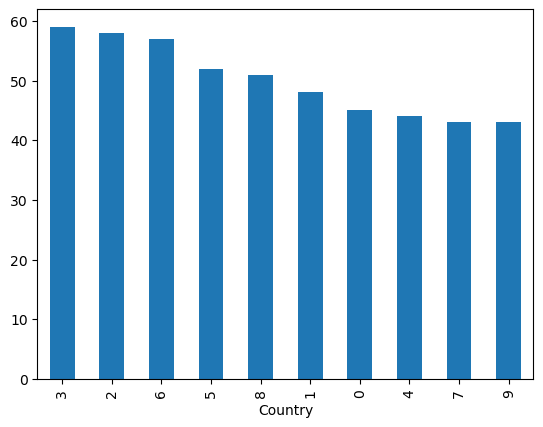

In [ ]:
df['Country'].value_counts().head(40).plot(kind='bar')

<function matplotlib.pyplot.show(close=None, block=None)>

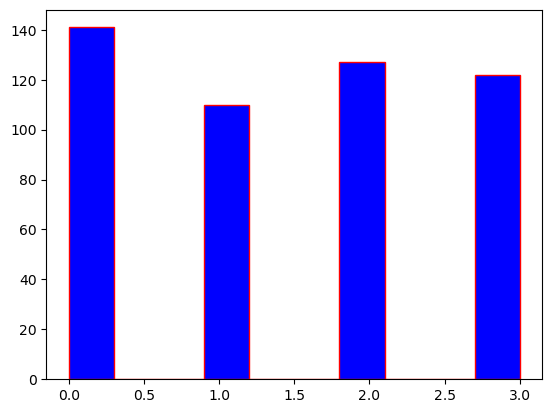

In [21]:
plt.hist(df['Sales_Channel'],bins=10,color='blue',edgecolor='red')
plt.show

(array([60., 54., 78., 65., 51., 65., 61., 66.]),
 array([ 2.52,  5.33,  8.14, 10.95, 13.76, 16.57, 19.38, 22.19, 25.  ]),
 <BarContainer object of 8 artists>)

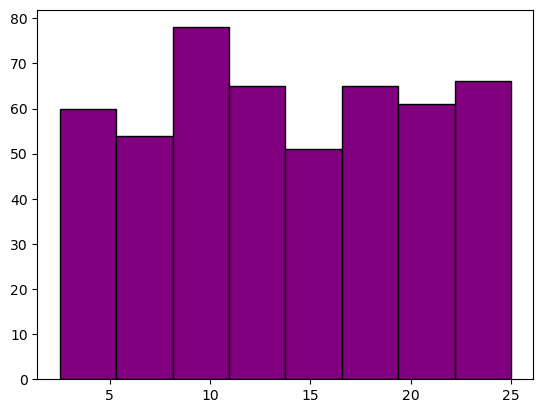

In [24]:
plt.hist(df['Price_USD'],bins=8,color='purple',edgecolor='black')